# 🏷 Notebook 2: Classification Comparison — CNN vs RNN vs Transformer
Train 3 custom classifiers on 80×80 labeled RBC images (9 classes).
**Metrics:** Accuracy, Macro F1, Confusion Matrix

In [2]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
torch.manual_seed(42)


Device: cpu


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
DATASET_BASE = r"c:\Users\DELL\Desktop\Vinh Hoang\Master Program\Học sâu\Project\Dataset"
# from google.colab import drive; drive.mount('/content/drive')
# DATASET_BASE = "/content/drive/MyDrive/Project/Dataset"

CLS_DIR       = os.path.join(DATASET_BASE, "Elsafty_RBCs_for_Classification", "Cropped images")
IMG_SIZE      = 80
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-3
SAMPLES_PER_CLASS = 1500   # set lower (e.g. 800) if RAM is limited

RESULTS_DIR = os.path.join(os.path.dirname(DATASET_BASE), "results", "classification")
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Config OK")


Config OK


In [4]:
# ── Dataset Loading & Stratified Split ───────────────────────────────────────────────────────────────────
import zipfile, shutil
from pathlib import Path
import random
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from PIL import Image

cls_dir_path = Path(CLS_DIR)

# 1. Tự động giải nén tất cả các file zip nếu có
for z in cls_dir_path.glob("*.zip"):
    print(f"Bung file nén: {z.name} ...")
    with zipfile.ZipFile(z, 'r') as zf:
        zf.extractall(cls_dir_path)

# 2. Dọn dẹp: Xóa các thư mục rỗng hoặc không chứa ảnh
for d in list(cls_dir_path.iterdir()):
    if d.is_dir() and not d.name.startswith('.'):
        has_png = any(d.rglob("*.png"))
        if not has_png:
            shutil.rmtree(d)

# 3. Lấy danh sách class
CLASSES = sorted([d.name for d in cls_dir_path.iterdir() if d.is_dir() and any(d.glob("*.png"))])
print(f"Classes ({len(CLASSES)}): {CLASSES}")
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

class RBCClsDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        base = [transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3)]
        aug  = [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15)]
        self.tf = transforms.Compose((aug if augment else []) + base)

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.tf(Image.open(path).convert("RGB")), label

def load_samples(cls_dir, spc, classes):
    samples = []
    for cls in classes:
        folder = Path(cls_dir) / cls
        files  = sorted(folder.glob("*.png"))
        if len(files) == 0: continue
        chosen = random.sample(list(files), min(spc, len(files)))
        for f in chosen:
            samples.append((str(f), CLASS2IDX[cls]))
    random.shuffle(samples)
    return samples

# --- EXECUTE LOADING ---
all_samples = load_samples(CLS_DIR, SAMPLES_PER_CLASS, CLASSES)
print(f"Total samples before split: {len(all_samples)}")

# --- START FIX: STRATIFIED SPLIT ---
all_paths = [s[0] for s in all_samples]
all_labels = [s[1] for s in all_samples]

train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.15, random_state=42, stratify=all_labels
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.1765, random_state=42, stratify=train_val_labels
)

train_s = list(zip(train_paths, train_labels))
val_s = list(zip(val_paths, val_labels))
test_s = list(zip(test_paths, test_labels))

train_ds = RBCClsDataset(train_s, augment=True)
val_ds   = RBCClsDataset(val_s)
test_ds  = RBCClsDataset(test_s)

class_counts = Counter(train_labels)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=(DEVICE=="cuda"))
val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
print(f"Train/Val/Test Datasets: {len(train_s)}/{len(val_s)}/{len(test_s)}")


Bung file nén: CROPPED - Class 1 - Rounded RBCs.zip ...
Bung file nén: CROPPED - Class 2 - Ovalocytes.zip ...
Bung file nén: CROPPED - Class 3 - Fragmented RBCs.zip ...
Bung file nén: CROPPED - Class 4 - Two Overlapping RBCs.zip ...
Bung file nén: CROPPED - Class 5 - Three Overlapping RBCs.zip ...
Bung file nén: CROPPED - Class 6 - Burr Cells.zip ...
Bung file nén: CROPPED - Class 7 - Teardrops.zip ...
Bung file nén: CROPPED - Class 8 - Angled Cells.zip ...
Bung file nén: CROPPED - Class 9 - Borderline Ovalocytes.zip ...
Classes (9): ['CROPPED - Class 1 - Rounded RBCs', 'CROPPED - Class 2 - Ovalocytes', 'CROPPED - Class 3 - Fragmented RBCs', 'CROPPED - Class 4 - Two Overlapping RBCs', 'CROPPED - Class 5 - Three Overlapping RBCs', 'CROPPED - Class 6 - Burr Cells', 'CROPPED - Class 7 - Teardrops', 'CROPPED - Class 8 - Angled Cells', 'CROPPED - Class 9 - Borderline Ovalocytes']
Total samples before split: 13500
Train/Val/Test Datasets: 9449/2026/2025


## 🏗 Model Architectures
### Pipeline A — Custom CNN Classifier

In [4]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(1, channels // reduction), 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(1, channels // reduction), channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(nn.Conv2d(2, 1, 7, padding=3, bias=False), nn.Sigmoid())
    def forward(self, x):
        x = x * self.ca(x); max_o, _ = torch.max(x, dim=1, keepdim=True); avg_o = torch.mean(x, dim=1, keepdim=True)
        return x * self.sa(torch.cat([max_o, avg_o], dim=1))

class CNNClassifier(nn.Module):
    def __init__(self, n_classes=9):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.cbam1  = CBAM(32)
        self.layer2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.cbam2  = CBAM(64)
        self.layer3 = nn.Sequential(nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128),nn.ReLU(), nn.MaxPool2d(2))
        self.cbam3  = CBAM(128)
        self.layer4 = nn.Sequential(nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256),nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, n_classes))

    def forward(self, x):
        x = self.cbam1(self.layer1(x))
        x = self.cbam2(self.layer2(x))
        x = self.cbam3(self.layer3(x))
        x = self.layer4(x)
        return self.head(x)

model_cnn = CNNClassifier(n_classes=len(CLASSES)).to(DEVICE)
print(f"CNN params: {sum(p.numel() for p in model_cnn.parameters()):,}")


CNN params: 394,671


### Pipeline B — Custom RNN (BiGRU) Classifier

In [5]:
class BiGRUClassifier(nn.Module):
    """Treat each row of the 80×80 image as a time step (seq_len=80, input=80*3=240)."""
    def __init__(self, n_classes=9, hidden=128, n_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(IMG_SIZE * 3, hidden)
        self.gru = nn.GRU(hidden, hidden, n_layers, batch_first=True,
                          bidirectional=True, dropout=0.3)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes))

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B, H, W * C)  # B, H, W*C
        x = self.input_proj(x)                            # B, H, hidden
        out, _ = self.gru(x)                              # B, H, hidden*2
        return self.head(out[:, -1, :])                   # last timestep

model_rnn = BiGRUClassifier(n_classes=len(CLASSES)).to(DEVICE)
print(f"BiGRU params: {sum(p.numel() for p in model_rnn.parameters()):,}")


BiGRU params: 559,497


### Pipeline C — Custom Vision Transformer (ViT) Classifier

In [6]:
class TransBlock(nn.Module):
    def __init__(self, dim=128, heads=4, mlp_ratio=3, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, dim*mlp_ratio), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim*mlp_ratio, dim), nn.Dropout(drop))
    def forward(self, x):
        n = self.norm1(x); x = x + self.attn(n,n,n)[0]
        return x + self.mlp(self.norm2(x))

class ViTClassifier(nn.Module):
    def __init__(self, img_size=80, patch_size=8, in_ch=3, n_classes=9,
                 embed_dim=128, depth=4, heads=4):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2
        self.patch_proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed  = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim) * 0.02)
        self.blocks     = nn.Sequential(*[TransBlock(embed_dim, heads) for _ in range(depth)])
        self.norm       = nn.LayerNorm(embed_dim)
        self.head       = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_proj(x).flatten(2).transpose(1,2)   # B, N, E
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed  # B, N+1, E
        x   = self.norm(self.blocks(x))
        return self.head(x[:, 0])                           # CLS token

model_vit = ViTClassifier(n_classes=len(CLASSES)).to(DEVICE)
print(f"ViT params:  {sum(p.numel() for p in model_vit.parameters()):,}")


ViT params:  700,681


## 🏋 Training

In [7]:
def train_cls(model, name, epochs=EPOCHS, lr=LR):
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # Dùng ReduceLROnPlateau thay cho Cosine để adaptive hơn với Early Stopping
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=3, factor=0.5)
    # Kỹ thuật: Label Smoothing (0.1) giúp model chống overfitting và tự tin thái quá
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    early_stop_patience = 10
    min_delta = 0.003
    epochs_no_improve = 0

    best_acc, best_state = 0., None
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(imgs), labels)
            loss.backward()
            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            running += loss.item()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs).argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        acc = correct / total
        sched.step(acc)

        history["train_loss"].append(running / len(train_dl))
        history["val_acc"].append(acc)

        if acc > best_acc + min_delta:
            best_acc  = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if True:  # Log every epoch as requested
            curr_lr = opt.param_groups[0]['lr']
            print(f"[{name}] Epoch {epoch:3d}/{epochs} | LR {curr_lr:.1e} | "
                  f"Loss {running/len(train_dl):.4f} | Val Acc {acc:.4f}")
                  
        if epochs_no_improve >= early_stop_patience:
            print(f"🛑 Early stopping tại epoch {epoch} (Không cải thiện sau {early_stop_patience} epochs)")
            break

    model.load_state_dict(best_state)
    torch.save(best_state, f"{RESULTS_DIR}/{name}_best.pt")
    print(f"✅ {name} best Val Acc = {best_acc:.4f}")
    return history


In [8]:
t0=time.time(); hist_cnn = train_cls(model_cnn, "CNN_Cls")
print(f"⏱ {(time.time()-t0)/60:.1f} min\n")
t0=time.time(); hist_rnn = train_cls(model_rnn, "RNN_Cls")
print(f"⏱ {(time.time()-t0)/60:.1f} min\n")
t0=time.time(); hist_vit = train_cls(model_vit, "ViT_Cls")
print(f"⏱ {(time.time()-t0)/60:.1f} min")


[CNN_Cls] Epoch   1/50 | LR 1.0e-03 | Loss 1.8536 | Val Acc 0.4116
[CNN_Cls] Epoch   2/50 | LR 1.0e-03 | Loss 1.5076 | Val Acc 0.5064
[CNN_Cls] Epoch   3/50 | LR 1.0e-03 | Loss 1.3678 | Val Acc 0.5829
[CNN_Cls] Epoch   4/50 | LR 1.0e-03 | Loss 1.2459 | Val Acc 0.6318
[CNN_Cls] Epoch   5/50 | LR 1.0e-03 | Loss 1.1383 | Val Acc 0.6382
[CNN_Cls] Epoch   6/50 | LR 1.0e-03 | Loss 1.0782 | Val Acc 0.6742
[CNN_Cls] Epoch   7/50 | LR 1.0e-03 | Loss 1.0311 | Val Acc 0.7024
[CNN_Cls] Epoch   8/50 | LR 1.0e-03 | Loss 1.0051 | Val Acc 0.7611
[CNN_Cls] Epoch   9/50 | LR 1.0e-03 | Loss 0.9750 | Val Acc 0.8031
[CNN_Cls] Epoch  10/50 | LR 1.0e-03 | Loss 0.9686 | Val Acc 0.7374
[CNN_Cls] Epoch  11/50 | LR 1.0e-03 | Loss 0.9503 | Val Acc 0.7887
[CNN_Cls] Epoch  12/50 | LR 1.0e-03 | Loss 0.9271 | Val Acc 0.8006
[CNN_Cls] Epoch  13/50 | LR 5.0e-04 | Loss 0.9294 | Val Acc 0.8026
[CNN_Cls] Epoch  14/50 | LR 5.0e-04 | Loss 0.8789 | Val Acc 0.8381
[CNN_Cls] Epoch  15/50 | LR 5.0e-04 | Loss 0.8696 | Val Acc 0.

## 📊 Evaluation

In [9]:
def evaluate_cls(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

results_cls = {}
for m, name in [(model_cnn,"CNN"), (model_rnn,"RNN"), (model_vit,"ViT")]:
    preds, labels = evaluate_cls(m, test_dl)
    report = classification_report(labels, preds, target_names=CLASSES, output_dict=True)
    results_cls[name] = {
        "Accuracy": report["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "preds": preds, "labels": labels,
    }
    print(f"\n{'='*50}")
    print(f"  {name} — Accuracy: {report['accuracy']:.4f}  Macro F1: {report['macro avg']['f1-score']:.4f}")
    print(classification_report(labels, preds, target_names=CLASSES))



  CNN — Accuracy: 0.9077  Macro F1: 0.9071
                                            precision    recall  f1-score   support

          CROPPED - Class 1 - Rounded RBCs       0.87      0.98      0.92       225
            CROPPED - Class 2 - Ovalocytes       0.89      0.88      0.88       225
       CROPPED - Class 3 - Fragmented RBCs       0.97      0.99      0.98       225
  CROPPED - Class 4 - Two Overlapping RBCs       0.91      0.91      0.91       225
CROPPED - Class 5 - Three Overlapping RBCs       0.92      0.90      0.91       225
            CROPPED - Class 6 - Burr Cells       0.96      0.98      0.97       225
             CROPPED - Class 7 - Teardrops       0.95      0.92      0.93       225
          CROPPED - Class 8 - Angled Cells       0.80      0.86      0.83       225
 CROPPED - Class 9 - Borderline Ovalocytes       0.92      0.77      0.84       225

                                  accuracy                           0.91      2025
                              

Đang tiến hành đánh giá CNN...
✅ Loaded weights for CNN Model from c:\Users\DELL\Desktop\Vinh Hoang\Master Program\Học sâu\Project\results\classification/CNN_Cls_best.pt


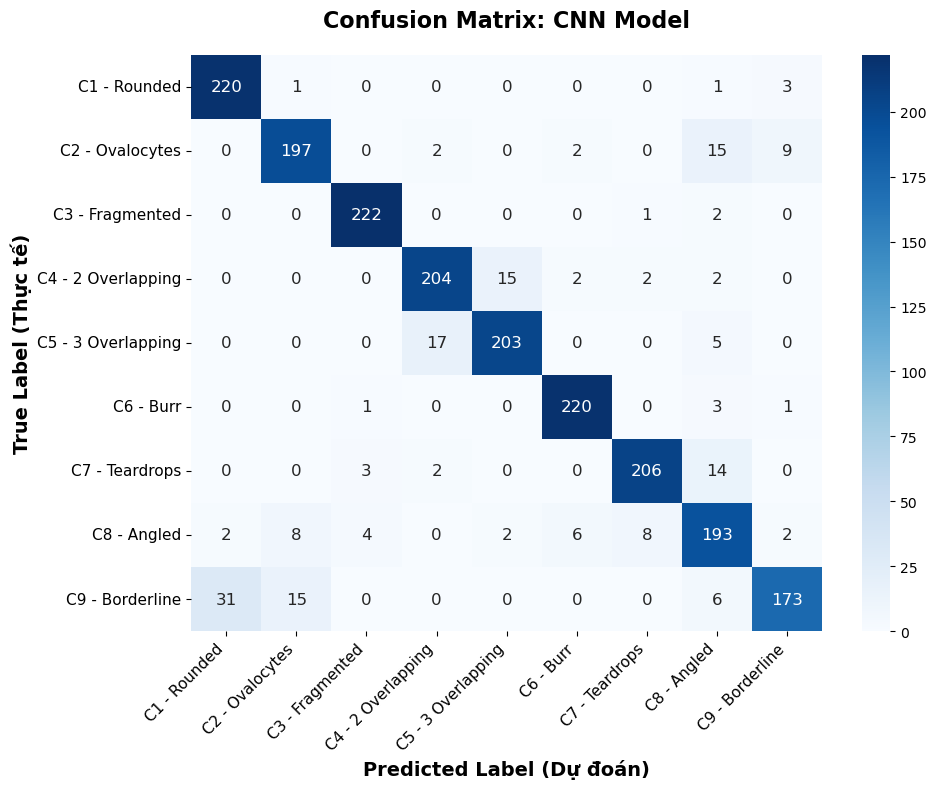


📊 [CNN Model] Classification Report:
                    precision    recall  f1-score   support

      C1 - Rounded     0.8696    0.9778    0.9205       225
   C2 - Ovalocytes     0.8914    0.8756    0.8834       225
   C3 - Fragmented     0.9652    0.9867    0.9758       225
C4 - 2 Overlapping     0.9067    0.9067    0.9067       225
C5 - 3 Overlapping     0.9227    0.9022    0.9124       225
         C6 - Burr     0.9565    0.9778    0.9670       225
    C7 - Teardrops     0.9493    0.9156    0.9321       225
       C8 - Angled     0.8008    0.8578    0.8283       225
   C9 - Borderline     0.9202    0.7689    0.8378       225

          accuracy                         0.9077      2025
         macro avg     0.9092    0.9077    0.9071      2025
      weighted avg     0.9092    0.9077    0.9071      2025

--------------------------------------------------------------------------------

Đang tiến hành đánh giá RNN...
✅ Loaded weights for RNN Model from c:\Users\DELL\Desktop\Vinh Hoa

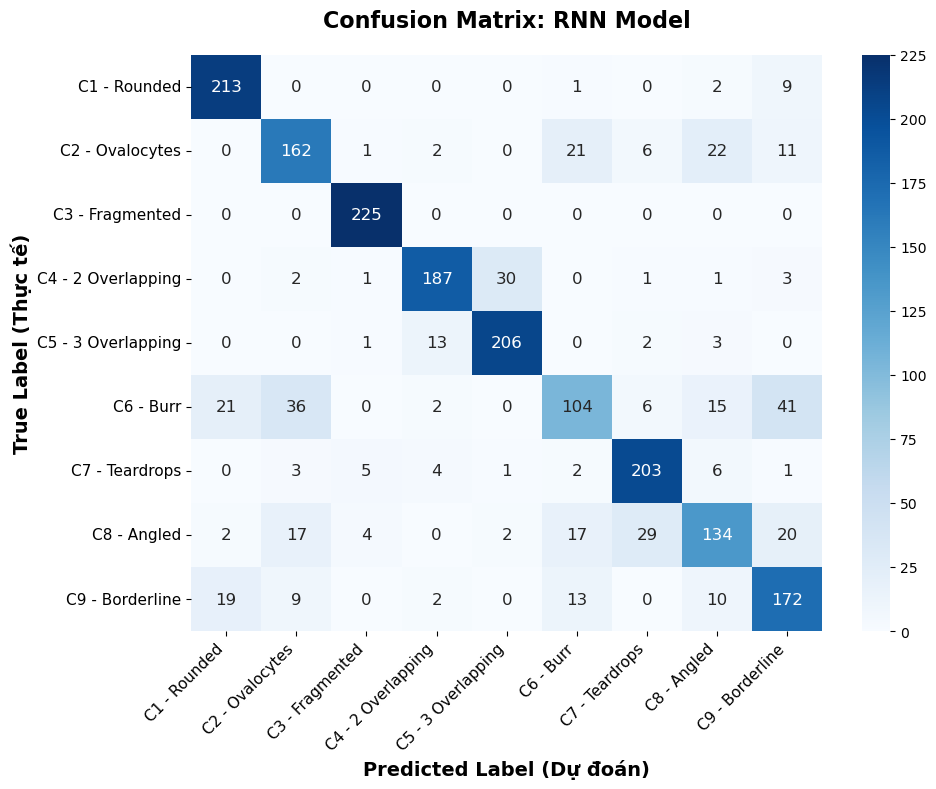


📊 [RNN Model] Classification Report:
                    precision    recall  f1-score   support

      C1 - Rounded     0.8353    0.9467    0.8875       225
   C2 - Ovalocytes     0.7074    0.7200    0.7137       225
   C3 - Fragmented     0.9494    1.0000    0.9740       225
C4 - 2 Overlapping     0.8905    0.8311    0.8598       225
C5 - 3 Overlapping     0.8619    0.9156    0.8879       225
         C6 - Burr     0.6582    0.4622    0.5431       225
    C7 - Teardrops     0.8219    0.9022    0.8602       225
       C8 - Angled     0.6943    0.5956    0.6411       225
   C9 - Borderline     0.6693    0.7644    0.7137       225

          accuracy                         0.7931      2025
         macro avg     0.7876    0.7931    0.7868      2025
      weighted avg     0.7876    0.7931    0.7868      2025

--------------------------------------------------------------------------------

Đang tiến hành đánh giá ViT...
✅ Loaded weights for Vision Transformer from c:\Users\DELL\Desktop

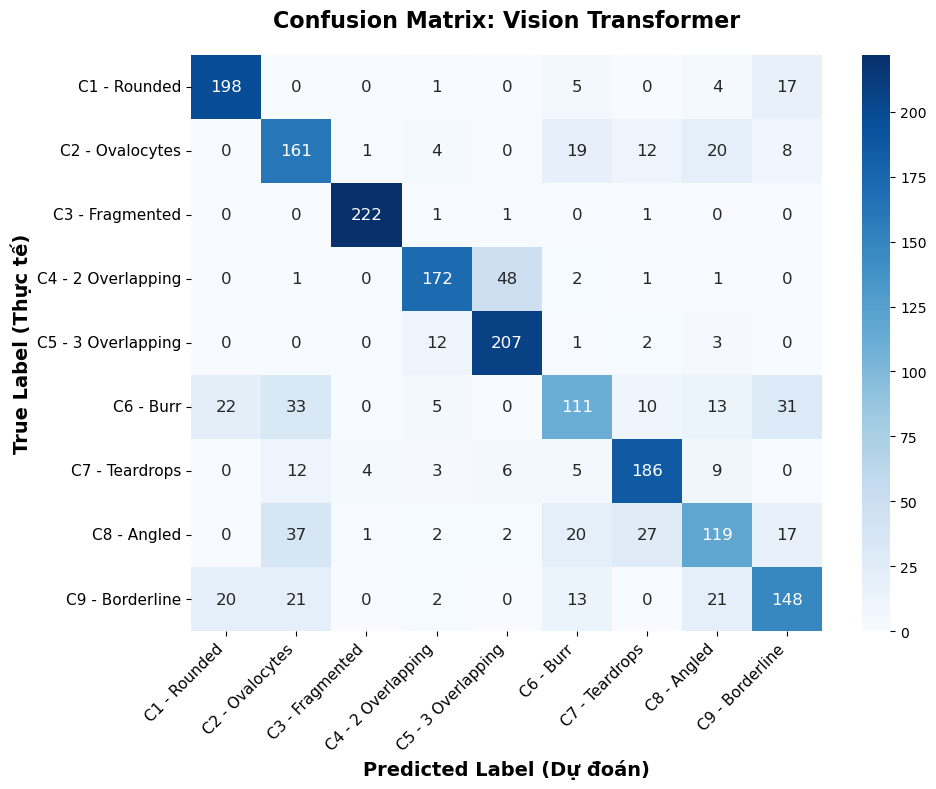


📊 [Vision Transformer] Classification Report:
                    precision    recall  f1-score   support

      C1 - Rounded     0.8250    0.8800    0.8516       225
   C2 - Ovalocytes     0.6075    0.7156    0.6571       225
   C3 - Fragmented     0.9737    0.9867    0.9801       225
C4 - 2 Overlapping     0.8515    0.7644    0.8056       225
C5 - 3 Overlapping     0.7841    0.9200    0.8466       225
         C6 - Burr     0.6307    0.4933    0.5536       225
    C7 - Teardrops     0.7782    0.8267    0.8017       225
       C8 - Angled     0.6263    0.5289    0.5735       225
   C9 - Borderline     0.6697    0.6578    0.6637       225

          accuracy                         0.7526      2025
         macro avg     0.7496    0.7526    0.7482      2025
      weighted avg     0.7496    0.7526    0.7482      2025

--------------------------------------------------------------------------------


In [10]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Rút gọn tên trục X, Y cho biểu đồ đỡ rối
SHORT_CLASSES = [
    "C1 - Rounded", "C2 - Ovalocytes", "C3 - Fragmented", 
    "C4 - 2 Overlapping", "C5 - 3 Overlapping", "C6 - Burr", 
    "C7 - Teardrops", "C8 - Angled", "C9 - Borderline"
]

# 2. Hàm Load Tạ (Weights) & Vẽ Biểu Đồ Rời
def evaluate_and_plot(model, weight_name, title):
    weight_path = f"{RESULTS_DIR}/{weight_name}_best.pt"
    
    # Bốc file Weights từ results set lên model
    try:
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        print(f"✅ Loaded weights for {title} from {weight_path}")
    except Exception as e:
        print(f"❌ Không tìm thấy file {weight_path} . Vui lòng kiểm tra lại quá trình train.")
        return

    model.to(DEVICE)
    model.eval()
    
    true_labels = []
    pred_labels = []
    
    # Dự đoán lại Test Set
    with torch.no_grad():
        for imgs, labels in test_dl:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(dim=1)
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())
            
    # Vẽ Confusion Matrix riêng biệt, size to
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=SHORT_CLASSES, 
                yticklabels=SHORT_CLASSES,
                annot_kws={"size": 12}) # Chữ số bên trong to rõ
    
    plt.title(f"Confusion Matrix: {title}", fontsize=16, pad=20, fontweight='bold')
    plt.ylabel('True Label (Thực tế)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label (Dự đoán)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # In báo cáo thông số chi tiết
    print(f"\n📊 [{title}] Classification Report:")
    print(classification_report(true_labels, pred_labels, target_names=SHORT_CLASSES, digits=4))
    print("-" * 80)

# 3. Chạy đánh giá và vẽ biểu đồ từng Model riêng rẽ
print("Đang tiến hành đánh giá CNN...")
evaluate_and_plot(model_cnn, "CNN_Cls", "CNN Model")

print("\nĐang tiến hành đánh giá RNN...")
evaluate_and_plot(model_rnn, "RNN_Cls", "RNN Model")

print("\nĐang tiến hành đánh giá ViT...")
evaluate_and_plot(model_vit, "ViT_Cls", "Vision Transformer")


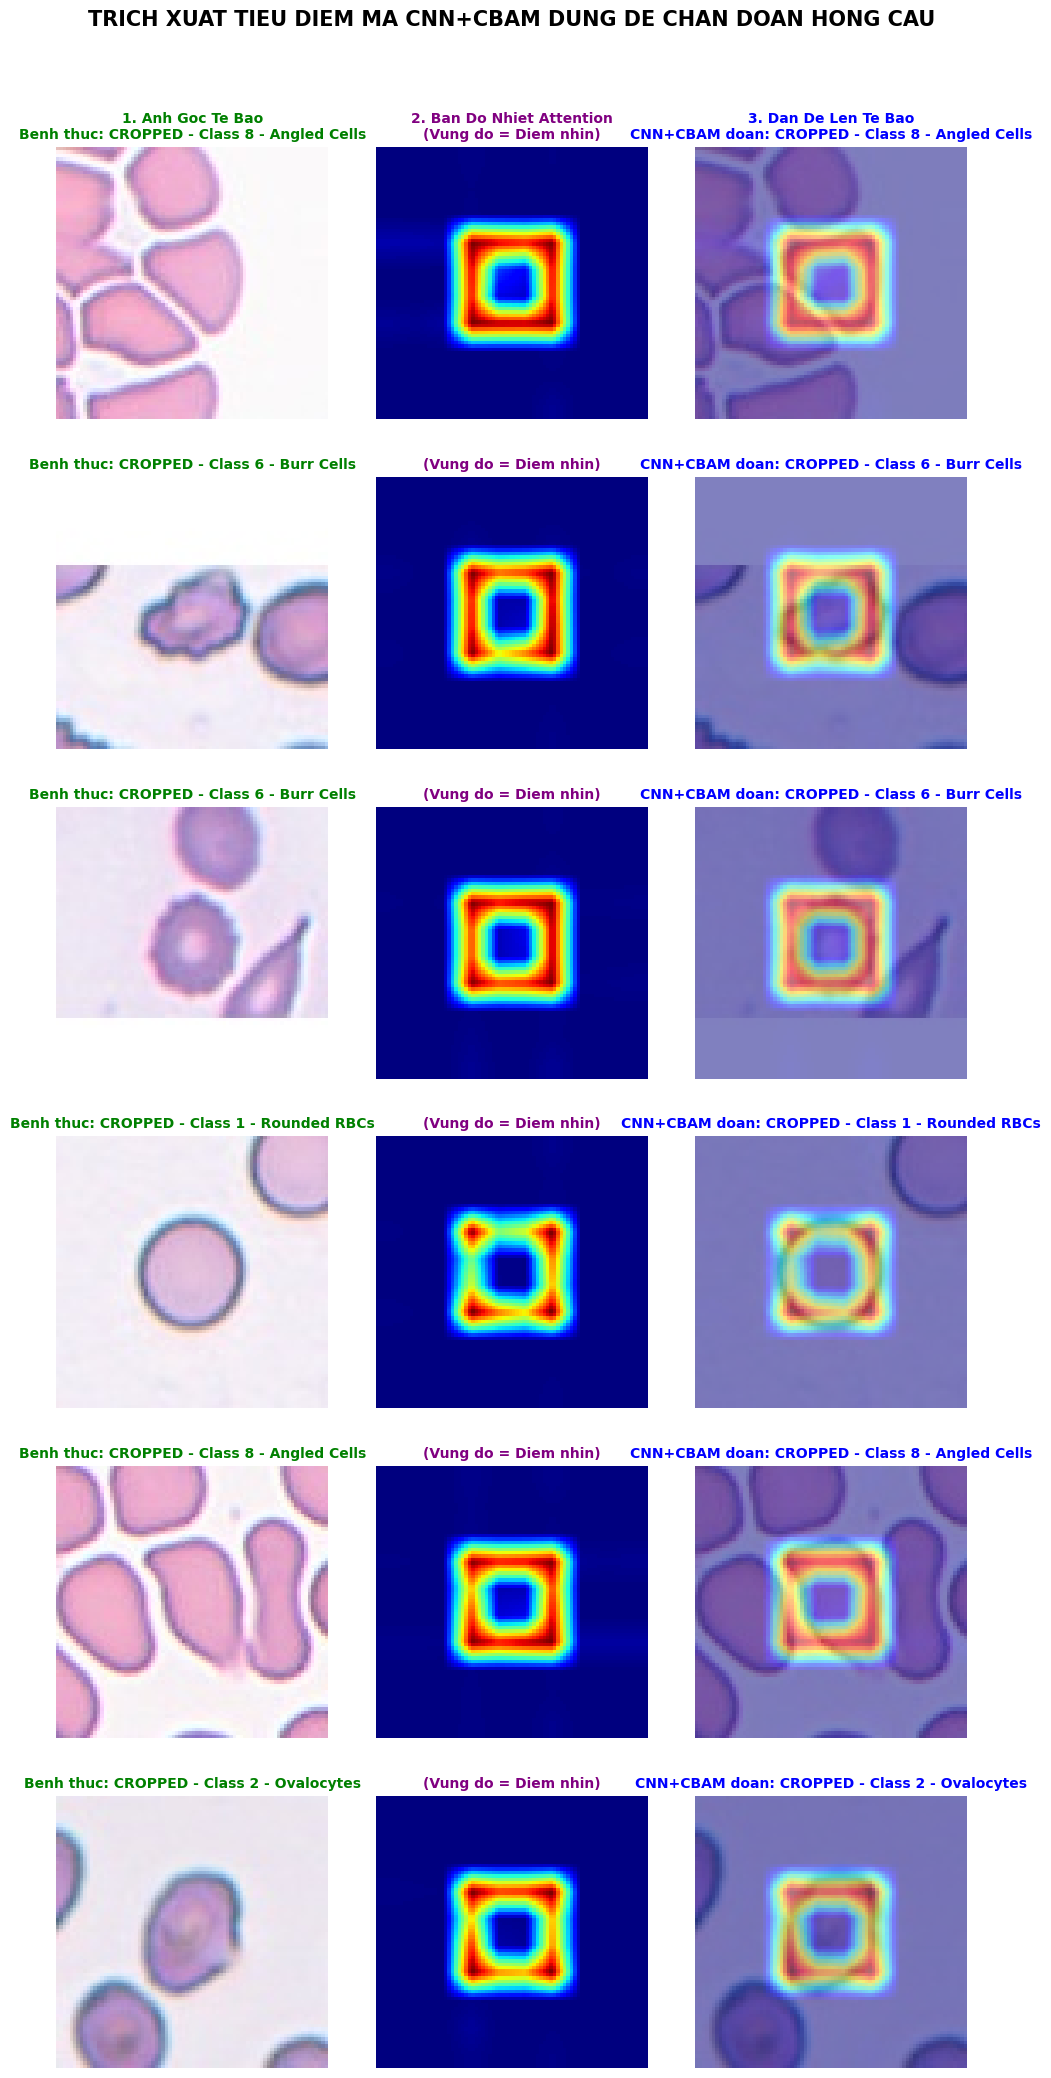

In [ ]:
# ==============================================================================
# HÀM MỔ XẺ X-QUANG HÀNG LOẠT (BẢN UPDATE)
# ==============================================================================
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'   

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from models_lib import CNNClassifier

# Lấy lại Model và rải đinh thu thập
model_xai = CNNClassifier(n_classes=len(CLASSES)).to(DEVICE)
model_xai.load_state_dict(torch.load(f"{RESULTS_DIR}/CNN_Cls_best.pt", map_location=DEVICE))
model_xai.eval()
thung_chua = {}
def tom_co_attention(ten_mang):
    def hook(module, input, output):
        thung_chua[ten_mang] = output.detach().cpu().numpy()
    return hook
model_xai.cbam3.sa.register_forward_hook(tom_co_attention('ban_do_nhiet'))

TF_XAI = transforms.Compose([
    transforms.Resize((80, 80)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ----------------------------------------------------
# CHỌN MỘT LÚC ĐA DẠNG ID ẢNH
list_id_anh = [0, 50, 150, 250, 550, 1000] 
num_imgs = len(list_id_anh)

plt.figure(figsize=(10, 3.5 * num_imgs)) # Tăng khoảng cách chiều cao xíu cho thoáng
plt.suptitle("TRICH XUAT TIEU DIEM MA CNN+CBAM DUNG DE CHAN DOAN HONG CAU", fontsize=15, fontweight='bold', y=1.0)

for row, id_anh in enumerate(list_id_anh):
    sample_path = test_paths[id_anh]
    true_label = test_labels[id_anh]
    img_goc = Image.open(sample_path).convert("RGB")
    img_tensor = TF_XAI(img_goc).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        pred_idx = torch.argmax(model_xai(img_tensor)).item()

    loi_giai_resized = cv2.resize(thung_chua['ban_do_nhiet'][0, 0, :, :], (80, 80))
    loi_giai_resized = np.clip(loi_giai_resized, 0, 1)
    img_goc_resize = img_goc.resize((80, 80))

    # Cột 1: Ảnh gốc
    plt.subplot(num_imgs, 3, row*3 + 1)
    title1 = "1. Anh Goc Te Bao\n" if row == 0 else ""
    plt.title(f"{title1}Benh thuc: {CLASSES[true_label]}", color="green", fontsize=10, fontweight='bold')
    plt.imshow(img_goc_resize)
    plt.axis('off')

    # Cột 2: Heatmap
    plt.subplot(num_imgs, 3, row*3 + 2)
    title2 = "2. Ban Do Nhiet Attention\n" if row == 0 else ""
    plt.title(f"{title2}(Vung do = Diem nhin)", color="purple", fontsize=10, fontweight='bold')
    plt.imshow(loi_giai_resized, cmap='jet')
    plt.axis('off')

    # Cột 3: Overlay
    plt.subplot(num_imgs, 3, row*3 + 3)
    c_color = "blue" if pred_idx == true_label else "red"
    title3 = "3. Dan De Len Te Bao\n" if row == 0 else ""
    plt.title(f"{title3}CNN+CBAM doan: {CLASSES[pred_idx]}", color=c_color, fontsize=10, fontweight='bold')
    plt.imshow(img_goc_resize)
    plt.imshow(loi_giai_resized, cmap='jet', alpha=0.5)
    plt.axis('off')

# Lệnh này tự động kéo giãn khoảng cách chữ giữa các hàng để không bị đè
plt.tight_layout(pad=3.0) 
plt.show()
